# Machine Learning Assignment - 2

## Comparative Analysis of Classification Models
### Dataset: UCI Dry Bean Dataset

**Models:**
1. Logistic Regression
2. Decision Tree
3. K-Nearest Neighbors
4. Gaussian Naive Bayes
5. Random Forest

**Evaluation Metrics:**
- Accuracy
- AUC
- Precision
- Recall
- F1 Score
- Matthews Correlation Coefficient (MCC)

In [39]:
import pandas as pd
import numpy as np

# Load the Dry Bean dataset
df = pd.read_excel("Dry_Bean_Dataset.xlsx")

# Display first five rows
df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [40]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nClass Distribution:")
print(df["Class"].value_counts())

Dataset Shape: (13611, 17)

Column Names:
['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4', 'Class']

Data Types:
Area                 int64
Perimeter          float64
MajorAxisLength    float64
MinorAxisLength    float64
AspectRation       float64
Eccentricity       float64
ConvexArea           int64
EquivDiameter      float64
Extent             float64
Solidity           float64
roundness          float64
Compactness        float64
ShapeFactor1       float64
ShapeFactor2       float64
ShapeFactor3       float64
ShapeFactor4       float64
Class               object
dtype: object

Missing Values:
0

Class Distribution:
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64


In [41]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 68


In [42]:
# Statistical summary of numerical features
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Area,13611.0,53048.284549,29324.095717,20420.000000,36328.000000,44652.000000,61332.000000,254616.000000
Perimeter,13611.0,855.283459,214.289696,524.736000,703.523500,794.941000,977.213000,1985.370000
MajorAxisLength,13611.0,320.141867,85.694186,183.601165,253.303633,296.883367,376.495012,738.860153
MinorAxisLength,13611.0,202.270714,44.970091,122.512653,175.848170,192.431733,217.031741,460.198497
AspectRation,13611.0,1.583242,0.246678,1.024868,1.432307,1.551124,1.707109,2.430306
Eccentricity,13611.0,0.750895,0.092002,0.218951,0.715928,0.764441,0.810466,0.911423
ConvexArea,13611.0,53768.200206,29774.915817,20684.000000,36714.500000,45178.000000,62294.000000,263261.000000
EquivDiameter,13611.0,253.064220,59.177120,161.243764,215.068003,238.438026,279.446467,569.374358
Extent,13611.0,0.749733,0.049086,0.555315,0.718634,0.759859,0.786851,0.866195
Solidity,13611.0,0.987143,0.004660,0.919246,0.985670,0.988283,0.990013,0.994677


In [43]:
# Class distribution in percentage
class_percentage = df["Class"].value_counts(normalize=True) * 100

print(class_percentage.round(2))

Class
DERMASON    26.05
SIRA        19.37
SEKER       14.89
HOROZ       14.17
CALI        11.98
BARBUNYA     9.71
BOMBAY       3.84
Name: proportion, dtype: float64


In [44]:
# Remove duplicate rows
df = df.drop_duplicates().reset_index(drop=True)

print("Dataset shape after removing duplicates:", df.shape)
print("Duplicate rows after removal:", df.duplicated().sum())

# Updated class distribution
print("\nUpdated class distribution:")
print(df["Class"].value_counts())

print("\nUpdated class proportions:")
print((df["Class"].value_counts(normalize=True) * 100).round(2))

Dataset shape after removing duplicates: (13543, 17)
Duplicate rows after removal: 0

Updated class distribution:
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1860
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64

Updated class proportions:
Class
DERMASON    26.18
SIRA        19.46
SEKER       14.97
HOROZ       13.73
CALI        12.04
BARBUNYA     9.76
BOMBAY       3.85
Name: proportion, dtype: float64


In [45]:
# Separate features and target

X = df.drop("Class", axis=1)
y = df["Class"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget classes:")
print(y.unique())

X shape: (13543, 16)
y shape: (13543,)

Features:
['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4']

Target classes:
['SEKER' 'BARBUNYA' 'BOMBAY' 'CALI' 'HOROZ' 'SIRA' 'DERMASON']


In [46]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Encoded classes:")
for number, class_name in enumerate(label_encoder.classes_):
    print(number, "=", class_name)

Encoded classes:
0 = BARBUNYA
1 = BOMBAY
2 = CALI
3 = DERMASON
4 = HOROZ
5 = SEKER
6 = SIRA


In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (10834, 16)
Testing set: (2709, 16)


In [48]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

Scaled training shape: (10834, 16)
Scaled testing shape: (2709, 16)


## Model 1: Logistic Regression

In [49]:
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

# Train the model
logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [50]:
# Predictions on test data
y_pred_lr = logistic_model.predict(X_test_scaled)

# Prediction probabilities
y_prob_lr = logistic_model.predict_proba(X_test_scaled)

print("Predictions generated successfully.")
print("Prediction shape:", y_pred_lr.shape)
print("Probability shape:", y_prob_lr.shape)

Predictions generated successfully.
Prediction shape: (2709,)
Probability shape: (2709, 7)


In [51]:
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef
)

# Logistic Regression metrics
accuracy_lr = accuracy_score(y_test, y_pred_lr)

auc_lr = roc_auc_score(
    y_test,
    y_prob_lr,
    multi_class="ovr",
    average="weighted"
)

precision_lr = precision_score(
    y_test,
    y_pred_lr,
    average="weighted"
)

recall_lr = recall_score(
    y_test,
    y_pred_lr,
    average="weighted"
)

f1_lr = f1_score(
    y_test,
    y_pred_lr,
    average="weighted"
)

mcc_lr = matthews_corrcoef(y_test, y_pred_lr)

print("Logistic Regression Results")
print("-" * 35)
print(f"Accuracy : {accuracy_lr:.4f}")
print(f"AUC      : {auc_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall   : {recall_lr:.4f}")
print(f"F1 Score : {f1_lr:.4f}")
print(f"MCC      : {mcc_lr:.4f}")

Logistic Regression Results
-----------------------------------
Accuracy : 0.9192
AUC      : 0.9934
Precision: 0.9197
Recall   : 0.9192
F1 Score : 0.9193
MCC      : 0.9023


Logistic Regression Confusion Matrix:
[[236   0  18   0   0   4   7]
 [  0 104   0   0   0   0   0]
 [  8   0 307   0   5   2   4]
 [  0   0   0 643   0  13  53]
 [  1   0  11   5 351   0   4]
 [  9   0   0   5   0 383   9]
 [  1   0   1  41   8  10 466]]


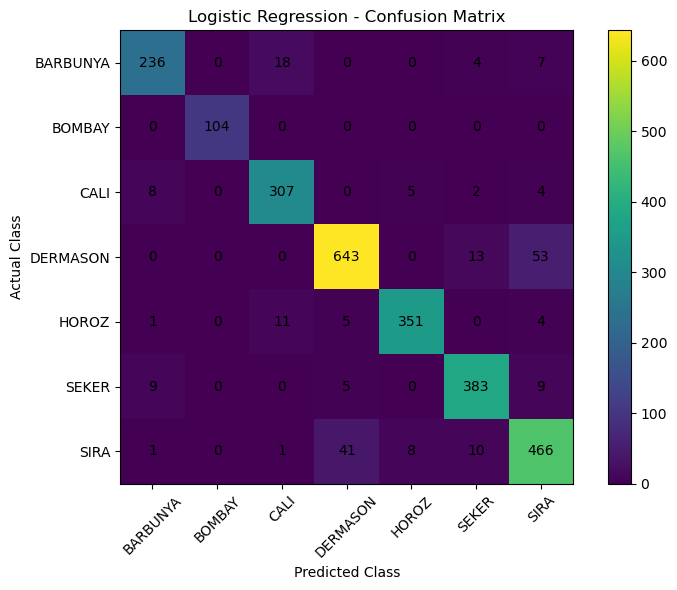

In [52]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Create confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)

print("Logistic Regression Confusion Matrix:")
print(cm_lr)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
plt.imshow(cm_lr)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.colorbar()

plt.xticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_,
    rotation=45
)

plt.yticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_
)

# Display values inside cells
for i in range(len(label_encoder.classes_)):
    for j in range(len(label_encoder.classes_)):
        plt.text(j, i, cm_lr[i, j],
                 ha="center",
                 va="center")

plt.tight_layout()
plt.show()

## Model 2: Decision Tree

In [53]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

decision_tree_model.fit(X_train, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [54]:
y_pred_dt = decision_tree_model.predict(X_test)
y_prob_dt = decision_tree_model.predict_proba(X_test)

print("Predictions generated successfully.")
print("Prediction shape:", y_pred_dt.shape)
print("Probability shape:", y_prob_dt.shape)

Predictions generated successfully.
Prediction shape: (2709,)
Probability shape: (2709, 7)


In [55]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)

auc_dt = roc_auc_score(
    y_test,
    y_prob_dt,
    multi_class="ovr",
    average="weighted"
)

precision_dt = precision_score(
    y_test,
    y_pred_dt,
    average="weighted"
)

recall_dt = recall_score(
    y_test,
    y_pred_dt,
    average="weighted"
)

f1_dt = f1_score(
    y_test,
    y_pred_dt,
    average="weighted"
)

mcc_dt = matthews_corrcoef(y_test, y_pred_dt)

print("Decision Tree Results")
print("-" * 35)
print(f"Accuracy : {accuracy_dt:.4f}")
print(f"AUC      : {auc_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall   : {recall_dt:.4f}")
print(f"F1 Score : {f1_dt:.4f}")
print(f"MCC      : {mcc_dt:.4f}")

Decision Tree Results
-----------------------------------
Accuracy : 0.8966
AUC      : 0.9363
Precision: 0.8965
Recall   : 0.8966
F1 Score : 0.8964
MCC      : 0.8750


Decision Tree Confusion Matrix:
[[239   0  16   1   0   3   6]
 [  0 104   0   0   0   0   0]
 [ 19   0 296   0   7   1   3]
 [  0   0   0 643   1  11  54]
 [  4   0  11   5 342   0  10]
 [  6   0   0  11   0 380   9]
 [  4   0   4  64   9  21 425]]


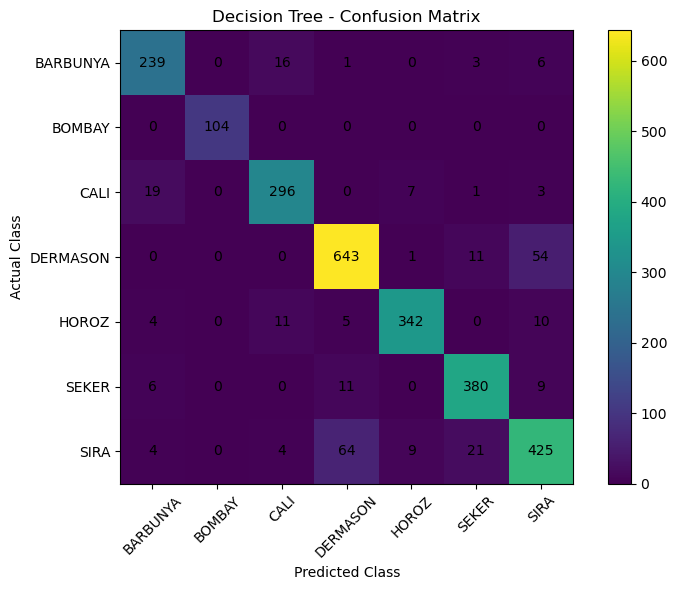

In [56]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

print("Decision Tree Confusion Matrix:")
print(cm_dt)

plt.figure(figsize=(8, 6))
plt.imshow(cm_dt)

plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.colorbar()

plt.xticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_,
    rotation=45
)

plt.yticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_
)

# Display values inside cells
for i in range(len(label_encoder.classes_)):
    for j in range(len(label_encoder.classes_)):
        plt.text(
            j, i, cm_dt[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

## Model 3: K-Nearest Neighbors (KNN)

In [57]:
X_train_scaled
X_test_scaled

array([[-0.426017  , -0.5455207 , -0.83511728, ...,  1.55931041,
         1.95524578,  0.35618169],
       [-0.71973677, -0.90444997, -0.8092735 , ...,  0.5212499 ,
         0.03115292,  0.59648765],
       [-0.67827806, -0.85216392, -0.87564231, ...,  0.90371132,
         0.60212224,  0.21161597],
       ...,
       [-0.48614404, -0.69891458, -0.86614892, ...,  1.50531987,
         1.76229452,  0.7766014 ],
       [-0.01660802, -0.10992947, -0.27014131, ...,  0.49078046,
         1.17290234,  0.68253284],
       [-0.13400054, -0.13848771, -0.25053412, ...,  0.21625333,
         0.58652521,  0.54715844]])

In [58]:
from sklearn.neighbors import KNeighborsClassifier

# Create KNN model
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the model using scaled data
knn_model.fit(X_train_scaled, y_train)

print("KNN model trained successfully.")

KNN model trained successfully.


In [59]:
# Generate predictions
y_pred_knn = knn_model.predict(X_test_scaled)

# Generate class probabilities
y_prob_knn = knn_model.predict_proba(X_test_scaled)

print("Predictions generated successfully.")
print("Prediction shape:", y_pred_knn.shape)
print("Probability shape:", y_prob_knn.shape)

Predictions generated successfully.
Prediction shape: (2709,)
Probability shape: (2709, 7)


In [60]:
accuracy_knn = accuracy_score(y_test, y_pred_knn)

auc_knn = roc_auc_score(
    y_test,
    y_prob_knn,
    multi_class="ovr",
    average="weighted"
)

precision_knn = precision_score(
    y_test,
    y_pred_knn,
    average="weighted"
)

recall_knn = recall_score(
    y_test,
    y_pred_knn,
    average="weighted"
)

f1_knn = f1_score(
    y_test,
    y_pred_knn,
    average="weighted"
)

mcc_knn = matthews_corrcoef(y_test, y_pred_knn)

print("KNN Results")
print("-" * 35)
print(f"Accuracy : {accuracy_knn:.4f}")
print(f"AUC      : {auc_knn:.4f}")
print(f"Precision: {precision_knn:.4f}")
print(f"Recall   : {recall_knn:.4f}")
print(f"F1 Score : {f1_knn:.4f}")
print(f"MCC      : {mcc_knn:.4f}")

KNN Results
-----------------------------------
Accuracy : 0.9155
AUC      : 0.9811
Precision: 0.9163
Recall   : 0.9155
F1 Score : 0.9157
MCC      : 0.8978


KNN Confusion Matrix:
[[232   0  21   0   1   3   8]
 [  0 104   0   0   0   0   0]
 [  8   0 309   0   5   2   2]
 [  0   0   0 647   0  10  52]
 [  0   0  13   4 347   0   8]
 [  6   0   1   7   0 380  12]
 [  3   0   0  49   8   6 461]]


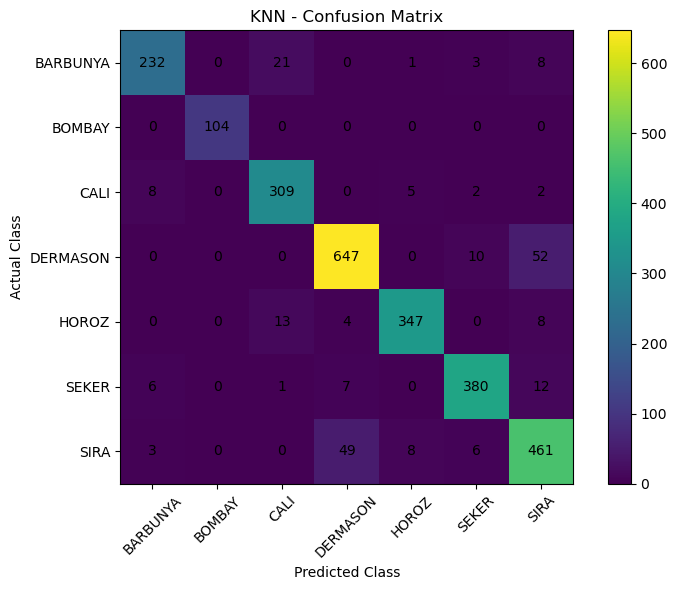

In [61]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

print("KNN Confusion Matrix:")
print(cm_knn)

plt.figure(figsize=(8, 6))
plt.imshow(cm_knn)

plt.title("KNN - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.colorbar()

plt.xticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_,
    rotation=45
)

plt.yticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_
)

for i in range(len(label_encoder.classes_)):
    for j in range(len(label_encoder.classes_)):
        plt.text(
            j, i, cm_knn[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

## Model 4 → Gaussian Naive Bayes

In [62]:
from sklearn.naive_bayes import GaussianNB

# Create Gaussian Naive Bayes model
nb_model = GaussianNB()

# Train the model
nb_model.fit(X_train_scaled, y_train)

print("Gaussian Naive Bayes model trained successfully.")

Gaussian Naive Bayes model trained successfully.


In [63]:
y_pred_nb = nb_model.predict(X_test_scaled)
y_prob_nb = nb_model.predict_proba(X_test_scaled)

print("Predictions generated successfully.")
print("Prediction shape:", y_pred_nb.shape)
print("Probability shape:", y_prob_nb.shape)

Predictions generated successfully.
Prediction shape: (2709,)
Probability shape: (2709, 7)


In [64]:
accuracy_nb = accuracy_score(y_test, y_pred_nb)

auc_nb = roc_auc_score(
    y_test,
    y_prob_nb,
    multi_class="ovr",
    average="weighted"
)

precision_nb = precision_score(
    y_test,
    y_pred_nb,
    average="weighted"
)

recall_nb = recall_score(
    y_test,
    y_pred_nb,
    average="weighted"
)

f1_nb = f1_score(
    y_test,
    y_pred_nb,
    average="weighted"
)

mcc_nb = matthews_corrcoef(y_test, y_pred_nb)

print("Gaussian Naive Bayes Results")
print("-" * 35)
print(f"Accuracy : {accuracy_nb:.4f}")
print(f"AUC      : {auc_nb:.4f}")
print(f"Precision: {precision_nb:.4f}")
print(f"Recall   : {recall_nb:.4f}")
print(f"F1 Score : {f1_nb:.4f}")
print(f"MCC      : {mcc_nb:.4f}")

Gaussian Naive Bayes Results
-----------------------------------
Accuracy : 0.8970
AUC      : 0.9899
Precision: 0.8997
Recall   : 0.8970
F1 Score : 0.8972
MCC      : 0.8762


Gaussian Naive Bayes Confusion Matrix:
[[211   0  40   0   1   2  11]
 [  0 104   0   0   0   0   0]
 [ 19   0 301   0   5   1   0]
 [  0   0   0 610   0  21  78]
 [  0   0  10   4 352   0   6]
 [  8   0   0   5   0 380  13]
 [  4   0   0  32  11   8 472]]


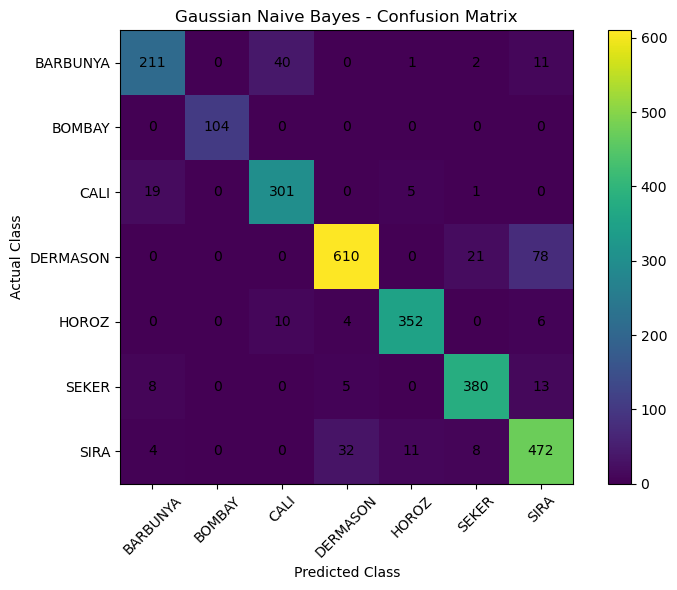

In [65]:
cm_nb = confusion_matrix(y_test, y_pred_nb)

print("Gaussian Naive Bayes Confusion Matrix:")
print(cm_nb)

plt.figure(figsize=(8, 6))
plt.imshow(cm_nb)

plt.title("Gaussian Naive Bayes - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.colorbar()

plt.xticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_,
    rotation=45
)

plt.yticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_
)

for i in range(len(label_encoder.classes_)):
    for j in range(len(label_encoder.classes_)):
        plt.text(
            j, i, cm_nb[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

## Model 5: Random Forest

In [66]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [67]:
# Generate predictions
y_pred_rf = rf_model.predict(X_test)

# Generate class probabilities
y_prob_rf = rf_model.predict_proba(X_test)

print("Predictions generated successfully.")
print("Prediction shape:", y_pred_rf.shape)
print("Probability shape:", y_prob_rf.shape)

Predictions generated successfully.
Prediction shape: (2709,)
Probability shape: (2709, 7)


In [68]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)

auc_rf = roc_auc_score(
    y_test,
    y_prob_rf,
    multi_class="ovr",
    average="weighted"
)

precision_rf = precision_score(
    y_test,
    y_pred_rf,
    average="weighted"
)

recall_rf = recall_score(
    y_test,
    y_pred_rf,
    average="weighted"
)

f1_rf = f1_score(
    y_test,
    y_pred_rf,
    average="weighted"
)

mcc_rf = matthews_corrcoef(y_test, y_pred_rf)

print("Random Forest Results")
print("-" * 35)
print(f"Accuracy : {accuracy_rf:.4f}")
print(f"AUC      : {auc_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1 Score : {f1_rf:.4f}")
print(f"MCC      : {mcc_rf:.4f}")

Random Forest Results
-----------------------------------
Accuracy : 0.9199
AUC      : 0.9907
Precision: 0.9199
Recall   : 0.9199
F1 Score : 0.9198
MCC      : 0.9031


Random Forest Confusion Matrix:
[[237   0  17   0   1   3   7]
 [  0 104   0   0   0   0   0]
 [ 10   0 306   0   5   2   3]
 [  0   0   0 655   0  12  42]
 [  1   0   8   3 351   0   9]
 [  3   0   0   6   0 389   8]
 [  3   0   1  56   7  10 450]]


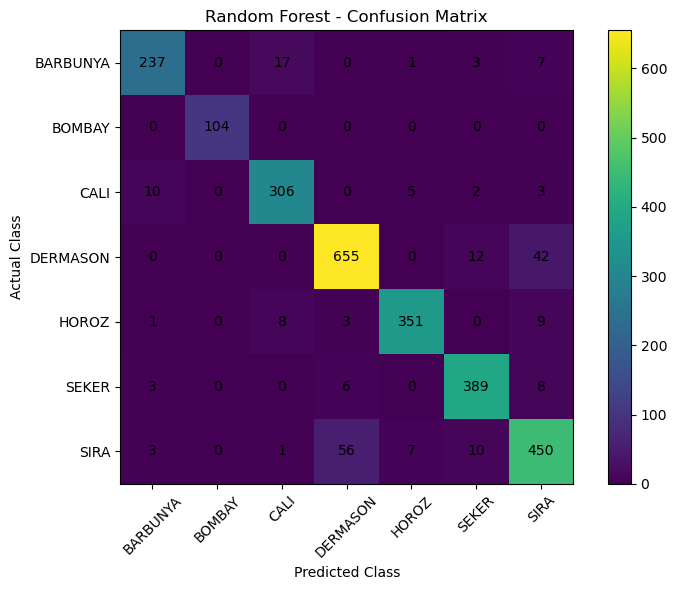

In [69]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Random Forest Confusion Matrix:")
print(cm_rf)

plt.figure(figsize=(8, 6))
plt.imshow(cm_rf)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.colorbar()

plt.xticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_,
    rotation=45
)

plt.yticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_
)

# Display values inside cells
for i in range(len(label_encoder.classes_)):
    for j in range(len(label_encoder.classes_)):
        plt.text(
            j, i, cm_rf[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [70]:
results = pd.DataFrame({
    "ML Model Name": [
        "Logistic Regression",
        "Decision Tree",
        "KNN",
        "Gaussian Naive Bayes",
        "Random Forest (Ensemble)"
    ],
    "Accuracy": [
        accuracy_lr,
        accuracy_dt,
        accuracy_knn,
        accuracy_nb,
        accuracy_rf
    ],
    "AUC": [
        auc_lr,
        auc_dt,
        auc_knn,
        auc_nb,
        auc_rf
    ],
    "Precision": [
        precision_lr,
        precision_dt,
        precision_knn,
        precision_nb,
        precision_rf
    ],
    "Recall": [
        recall_lr,
        recall_dt,
        recall_knn,
        recall_nb,
        recall_rf
    ],
    "F1": [
        f1_lr,
        f1_dt,
        f1_knn,
        f1_nb,
        f1_rf
    ],
    "MCC": [
        mcc_lr,
        mcc_dt,
        mcc_knn,
        mcc_nb,
        mcc_rf
    ]
})

# Display rounded values
results.round(4)

,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.9192,0.9934,0.9197,0.9192,0.9193,0.9023
1,Decision Tree,0.8966,0.9363,0.8965,0.8966,0.8964,0.8750
2,KNN,0.9155,0.9811,0.9163,0.9155,0.9157,0.8978
3,Gaussian Naive Bayes,0.8970,0.9899,0.8997,0.8970,0.8972,0.8762
4,Random Forest (Ensemble),0.9199,0.9907,0.9199,0.9199,0.9198,0.9031


Model Observations

1. Logistic Regression

Logistic Regression achieved strong overall performance with 91.92% accuracy and the highest AUC of 0.9934. This indicates excellent class-separation capability. Its MCC of 0.9023 also indicates strong agreement between predicted and actual classes.

2. Decision Tree

Decision Tree achieved 89.66% accuracy, which was the lowest accuracy among the five models. Its AUC of 0.9363 and MCC of 0.8750 were also lower than the other models, indicating comparatively weaker generalization on this dataset.

3. KNN

KNN achieved 91.55% accuracy and an F1-score of 0.9157. Its performance was close to Logistic Regression, although slightly lower across most metrics. Feature scaling was important for this model.

4. Gaussian Naive Bayes

Gaussian Naive Bayes achieved 89.70% accuracy, but its AUC was relatively high at 0.9899. This suggests strong probability-based class separation despite lower final classification accuracy.

5. Random Forest

Random Forest achieved the highest overall classification performance with 91.99% accuracy, 91.98% F1, and 0.9031 MCC. It therefore provides the best overall balance among the evaluated models.

In [71]:
print("Models available:")
print("Logistic Regression:", type(logistic_model))
print("Decision Tree:", type(decision_tree_model))
print("KNN:", type(knn_model))
print("Naive Bayes:", type(nb_model))
print("Random Forest:", type(rf_model))
print("Scaler:", type(scaler))
print("Label Encoder:", type(label_encoder))

Models available:
Logistic Regression: <class 'sklearn.linear_model._logistic.LogisticRegression'>
Decision Tree: <class 'sklearn.tree._classes.DecisionTreeClassifier'>
KNN: <class 'sklearn.neighbors._classification.KNeighborsClassifier'>
Naive Bayes: <class 'sklearn.naive_bayes.GaussianNB'>
Random Forest: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
Scaler: <class 'sklearn.preprocessing._data.StandardScaler'>
Label Encoder: <class 'sklearn.preprocessing._label.LabelEncoder'>


In [72]:
import os
import joblib

# Create models folder
os.makedirs("models", exist_ok=True)

# Save all trained models
joblib.dump(logistic_model, "models/logistic_regression.pkl")
joblib.dump(decision_tree_model, "models/decision_tree.pkl")
joblib.dump(knn_model, "models/knn.pkl")
joblib.dump(nb_model, "models/naive_bayes.pkl")
joblib.dump(rf_model, "models/random_forest.pkl")

# Save preprocessing objects
joblib.dump(scaler, "models/scaler.pkl")
joblib.dump(label_encoder, "models/label_encoder.pkl")

# Save feature names
joblib.dump(X.columns.tolist(), "models/feature_names.pkl")

print("All models and preprocessing objects saved successfully.")

All models and preprocessing objects saved successfully.


In [73]:
import os

print("Saved files:")
for file in os.listdir("models"):
    print(file)

Saved files:
naive_bayes.pkl
random_forest.pkl
scaler.pkl
label_encoder.pkl
logistic_regression.pkl
knn.pkl
feature_names.pkl
decision_tree.pkl


In [74]:
# Load the saved models back

loaded_rf = joblib.load("models/random_forest.pkl")
loaded_lr = joblib.load("models/logistic_regression.pkl")
loaded_dt = joblib.load("models/decision_tree.pkl")
loaded_knn = joblib.load("models/knn.pkl")
loaded_nb = joblib.load("models/naive_bayes.pkl")

loaded_scaler = joblib.load("models/scaler.pkl")
loaded_encoder = joblib.load("models/label_encoder.pkl")
loaded_features = joblib.load("models/feature_names.pkl")

print("Models loaded successfully.")
print("Random Forest:", type(loaded_rf))
print("Logistic Regression:", type(loaded_lr))
print("Decision Tree:", type(loaded_dt))
print("KNN:", type(loaded_knn))
print("Naive Bayes:", type(loaded_nb))
print("Scaler:", type(loaded_scaler))
print("Label Encoder:", type(loaded_encoder))
print("Number of features:", len(loaded_features))

Models loaded successfully.
Random Forest: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
Logistic Regression: <class 'sklearn.linear_model._logistic.LogisticRegression'>
Decision Tree: <class 'sklearn.tree._classes.DecisionTreeClassifier'>
KNN: <class 'sklearn.neighbors._classification.KNeighborsClassifier'>
Naive Bayes: <class 'sklearn.naive_bayes.GaussianNB'>
Scaler: <class 'sklearn.preprocessing._data.StandardScaler'>
Label Encoder: <class 'sklearn.preprocessing._label.LabelEncoder'>
Number of features: 16


In [75]:
# Create test_data.csv from the test set

test_data = X_test.copy()

# Add actual class for verification
test_data["Actual_Class"] = label_encoder.inverse_transform(y_test)

# Select 10 rows
test_data_10 = test_data.head(10)

# Save CSV
test_data_10.to_csv("test_data.csv", index=False)

print("test_data.csv created successfully.")
print("Shape:", test_data_10.shape)

display(test_data_10)

test_data.csv created successfully.
Shape: (10, 17)


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Actual_Class
1223,40512,737.636,248.202030,208.525152,1.190274,0.542365,40973,227.115566,0.744268,0.988749,0.935641,0.915043,0.006127,0.002650,0.837304,0.996621,SEKER
11769,31890,660.655,250.417300,162.522502,1.540816,0.760783,32240,201.503372,0.801962,0.989144,0.918153,0.804670,0.007853,0.002031,0.647494,0.997670,DERMASON
12059,33107,671.869,244.728317,172.938116,1.415121,0.707560,33506,205.312303,0.798683,0.988092,0.921638,0.838940,0.007392,0.002259,0.703820,0.995990,DERMASON
7126,61684,984.878,412.115648,191.473280,2.152340,0.885515,62303,280.247227,0.784724,0.990065,0.799130,0.680021,0.006681,0.000881,0.462428,0.995303,HOROZ
638,37189,700.253,243.343401,194.910062,1.248491,0.598708,37534,217.601713,0.784826,0.990808,0.953047,0.894217,0.006543,0.002581,0.799623,0.998322,SEKER
13211,38811,726.395,268.152340,184.902092,1.450240,0.724246,39206,222.296424,0.791657,0.989925,0.924313,0.828993,0.006909,0.002013,0.687229,0.996647,DERMASON
12549,35072,693.453,254.363667,176.252147,1.443181,0.721020,35397,211.317433,0.802214,0.990818,0.916508,0.830769,0.007253,0.002131,0.690177,0.996050,DERMASON
10682,27680,608.736,224.333880,157.289337,1.426250,0.713024,27937,187.731912,0.753341,0.990801,0.938681,0.836842,0.008105,0.002452,0.700304,0.998808,DERMASON
2639,68770,1032.496,353.782883,248.615876,1.423010,0.711451,69908,295.906545,0.755051,0.983721,0.810648,0.836407,0.005144,0.001553,0.699577,0.995505,BARBUNYA
11764,31878,667.718,254.704323,159.710474,1.594788,0.778985,32212,201.465457,0.757827,0.989631,0.898493,0.790978,0.007990,0.001929,0.625646,0.997772,DERMASON


In [76]:
import pandas as pd

test_check = pd.read_csv("test_data.csv")

print("CSV shape:", test_check.shape)

print("\nColumns:")
print(test_check.columns.tolist())

print("\nFirst 5 rows:")
display(test_check.head())

CSV shape: (10, 17)

Columns:
['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4', 'Actual_Class']

First 5 rows:


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Actual_Class
0,40512,737.636,248.202030,208.525152,1.190274,0.542365,40973,227.115566,0.744268,0.988749,0.935641,0.915043,0.006127,0.002650,0.837304,0.996621,SEKER
1,31890,660.655,250.417300,162.522502,1.540816,0.760783,32240,201.503372,0.801962,0.989144,0.918153,0.804670,0.007853,0.002031,0.647494,0.997670,DERMASON
2,33107,671.869,244.728317,172.938116,1.415121,0.707560,33506,205.312303,0.798683,0.988092,0.921638,0.838940,0.007392,0.002259,0.703820,0.995990,DERMASON
3,61684,984.878,412.115648,191.473280,2.152340,0.885515,62303,280.247227,0.784724,0.990065,0.799130,0.680021,0.006681,0.000881,0.462428,0.995303,HOROZ
4,37189,700.253,243.343401,194.910062,1.248491,0.598708,37534,217.601713,0.784826,0.990808,0.953047,0.894217,0.006543,0.002581,0.799623,0.998322,SEKER
